# Data Quality Check & Cleaning
Step-by-step: cek distribusi, corrupt, duplikat, ukuran, format, overlap, perceptual hash → backup → cleaning

In [1]:
import hashlib
import os
import shutil
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

%matplotlib inline

def _safe_path(p):
    p = str(p)
    if len(p) > 240 and not p.startswith('\\\\?\\'):
        return '\\\\?\\' + p
    return p

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
TRAIN_DIR = PROJECT_ROOT / 'data' / 'raw' / 'train'
TEST_DIR = PROJECT_ROOT / 'data' / 'raw' / 'test'
BACKUP_DIR = PROJECT_ROOT / 'data' / 'raw' / 'train_backup'

print(f'Project root: {PROJECT_ROOT}')
print(f'Train dir: {TRAIN_DIR}')
print(f'Test dir: {TEST_DIR}')
print(f'Train exists: {TRAIN_DIR.exists()}')

Project root: d:\Kuliah\LOMBA\Satria-Data\main\big-data-big-trouble
Train dir: d:\Kuliah\LOMBA\Satria-Data\main\big-data-big-trouble\data\raw\train
Test dir: d:\Kuliah\LOMBA\Satria-Data\main\big-data-big-trouble\data\raw\test
Train exists: True


---
## 1. Distribusi Kelas

Class Distribution:
Kelas                       Jumlah   Proporsi
---------------------------------------------
0_Recyclable                  9999    37.69%
1_Electronic                  3961    14.93%
2_Organic                    12567    47.37%
---------------------------------------------
TOTAL                        26527


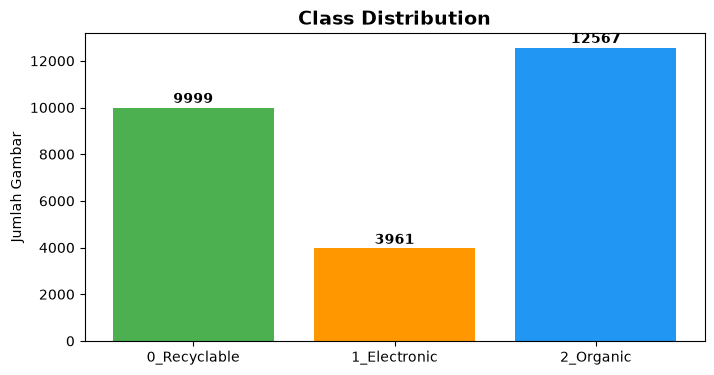

In [3]:
class_counts = {}
total = 0

for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = TRAIN_DIR / cls
    if not cls_path.is_dir():
        continue
    count = len(list(cls_path.iterdir()))
    class_counts[cls] = count
    total += count

print('Class Distribution:')
print(f"{'Kelas':<25} {'Jumlah':>8} {'Proporsi':>10}")
print('-' * 45)
for cls, count in sorted(class_counts.items()):
    pct = count / total * 100
    print(f'{cls:<25} {count:>8} {pct:>8.2f}%')
print('-' * 45)
print(f'{"TOTAL":<25} {total:>8}')

colors = ['#4CAF50', '#FF9800', '#2196F3']
plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values(), color=colors)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Gambar')
for i, (k, v) in enumerate(class_counts.items()):
    plt.text(i, v + 200, str(v), ha='center', fontweight='bold')
plt.show()

---
## 2. Format File

File Format Distribution:
  .jpg      26049 files
  .jpeg       430 files
  .png         48 files


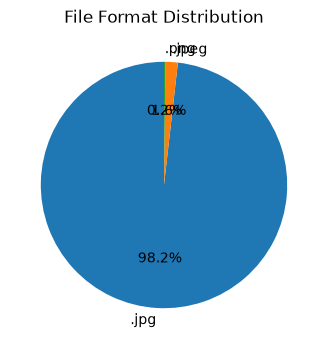

In [4]:
ext_counts = defaultdict(int)
for cls in os.listdir(TRAIN_DIR):
    cls_path = TRAIN_DIR / cls
    if not cls_path.is_dir():
        continue
    for fname in os.listdir(cls_path):
        ext = os.path.splitext(fname)[1].lower()
        ext_counts[ext] += 1

print('File Format Distribution:')
for ext, count in sorted(ext_counts.items(), key=lambda x: -x[1]):
    print(f'  {ext:<8} {count:>6} files')

plt.figure(figsize=(6, 4))
plt.pie(ext_counts.values(), labels=ext_counts.keys(), autopct='%1.1f%%', startangle=90)
plt.title('File Format Distribution')
plt.show()

---
## 3. Corrupt Images

In [5]:
corrupt = []
sample_count = 0

for cls in os.listdir(TRAIN_DIR):
    cls_path = TRAIN_DIR / cls
    if not cls_path.is_dir():
        continue
    for fpath in cls_path.iterdir():
        sample_count += 1
        try:
            with Image.open(_safe_path(fpath)) as img:
                img.verify()
        except Exception as e:
            corrupt.append((cls, fpath.name, str(e)))

print(f'Total images scanned: {sample_count}')
if corrupt:
    print(f'Corrupt images found: {len(corrupt)}')
    for cls, fname, err in corrupt[:10]:
        print(f'  {cls}/{fname} -> {err}')
else:
    print('No corrupt images found.')

Total images scanned: 26527
No corrupt images found.


---
## 4. Duplikat (MD5 Hash)

In [ ]:
hash_map = defaultdict(list)
total_hashed = 0

for cls in os.listdir(TRAIN_DIR):
    cls_path = TRAIN_DIR / cls
    if not cls_path.is_dir():
        continue
    for fpath in cls_path.iterdir():
        total_hashed += 1
        with open(_safe_path(fpath), 'rb') as f:
            h = hashlib.md5(f.read()).hexdigest()
        hash_map[h].append({'cls': cls, 'fname': fpath.name, 'path': fpath})

dup_groups = {h: v for h, v in hash_map.items() if len(v) > 1}
print(f'Total files hashed: {total_hashed}')
print(f'Unique images: {len(hash_map)}')
print(f'Duplicate groups: {len(dup_groups)}')

Total files hashed: 26527
Unique images: 26465
Duplicate groups: 62


In [ ]:
in_class = 0
cross_class = []
dup_by_class = defaultdict(int)

for h, files in dup_groups.items():
    classes = set(f['cls'] for f in files)
    if len(classes) > 1:
        cross_class.append(files)
    else:
        in_class += 1
        dup_by_class[list(classes)[0]] += len(files) - 1

dup_file_count = sum(len(v) for v in dup_groups.values())
excess = dup_file_count - len(dup_groups)

print(f'In-class duplicate groups: {in_class}')
print(f'Cross-class duplicate groups: {len(cross_class)} \u26a0\ufe0f')
print(f'Total excess files to remove: {excess}')
print()
print('Excess files per class:')
for cls, count in sorted(dup_by_class.items(), key=lambda x: -x[1]):
    print(f'  {cls}: {count}')

if cross_class:
    print(f'\n\u26a0\ufe0f  CROSS-CLASS DUPLICATES:')
    for files in cross_class:
        classes = set(f['cls'] for f in files)
        fnames = [f'{f["cls"]}/{f["fname"]}' for f in files]
        print(f'  {" = ".join(fnames)}  |  LABEL: {classes}')

In-class duplicate groups: 61
Cross-class duplicate groups: 1 ⚠️
Total excess files to remove: 62

Excess files per class:
  1_Electronic: 30
  2_Organic: 22
  0_Recyclable: 9

⚠️  CROSS-CLASS DUPLICATES:
  0_Recyclable/R_799.jpg = 2_Organic/O_8873.jpg  |  LABEL: {'2_Organic', '0_Recyclable'}


---
## 5. Ukuran Gambar (Sample)

Smalles size: 95x204
Larges size: 6016x4016

Top 10 sizes:
  275x183: 87
  225x225: 75
  259x194: 53
  300x168: 46
  299x168: 18
  4160x2340: 16
  276x183: 14
  1280x720: 13
  183x275: 10
  290x174: 9


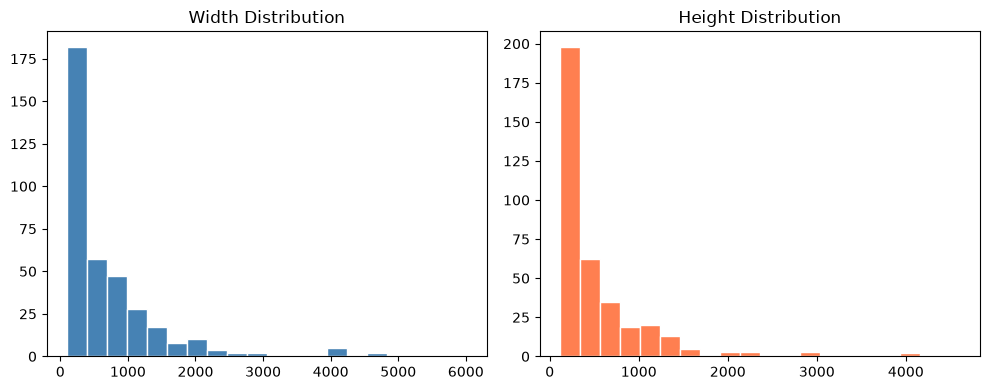

In [ ]:
size_map = defaultdict(int)
min_size = (9999, 9999)
max_size = (0, 0)

for cls in os.listdir(TRAIN_DIR):
    cls_path = TRAIN_DIR / cls
    if not cls_path.is_dir():
        continue
    for i, fpath in enumerate(cls_path.iterdir()):
        if i >= 300:
            break
        with Image.open(_safe_path(fpath)) as img:
            s = img.size
            size_map[s] += 1
            if s[0] * s[1] < min_size[0] * min_size[1]:
                min_size = s
            if s[0] * s[1] > max_size[0] * max_size[1]:
                max_size = s

print(f'Smalles size: {min_size[0]}x{min_size[1]}')
print(f'Larges size: {max_size[0]}x{max_size[1]}')
print(f'\nTop 10 sizes:')
for size, count in sorted(size_map.items(), key=lambda x: -x[1])[:10]:
    print(f'  {size[0]}x{size[1]}: {count}')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist([k[0] for k in size_map.keys()], bins=20, color='steelblue', edgecolor='white')
plt.title('Width Distribution')
plt.subplot(1, 2, 2)
plt.hist([k[1] for k in size_map.keys()], bins=20, color='coral', edgecolor='white')
plt.title('Height Distribution')
plt.tight_layout()
plt.show()

---
## 6. Sample Gambar Tiap Kelas

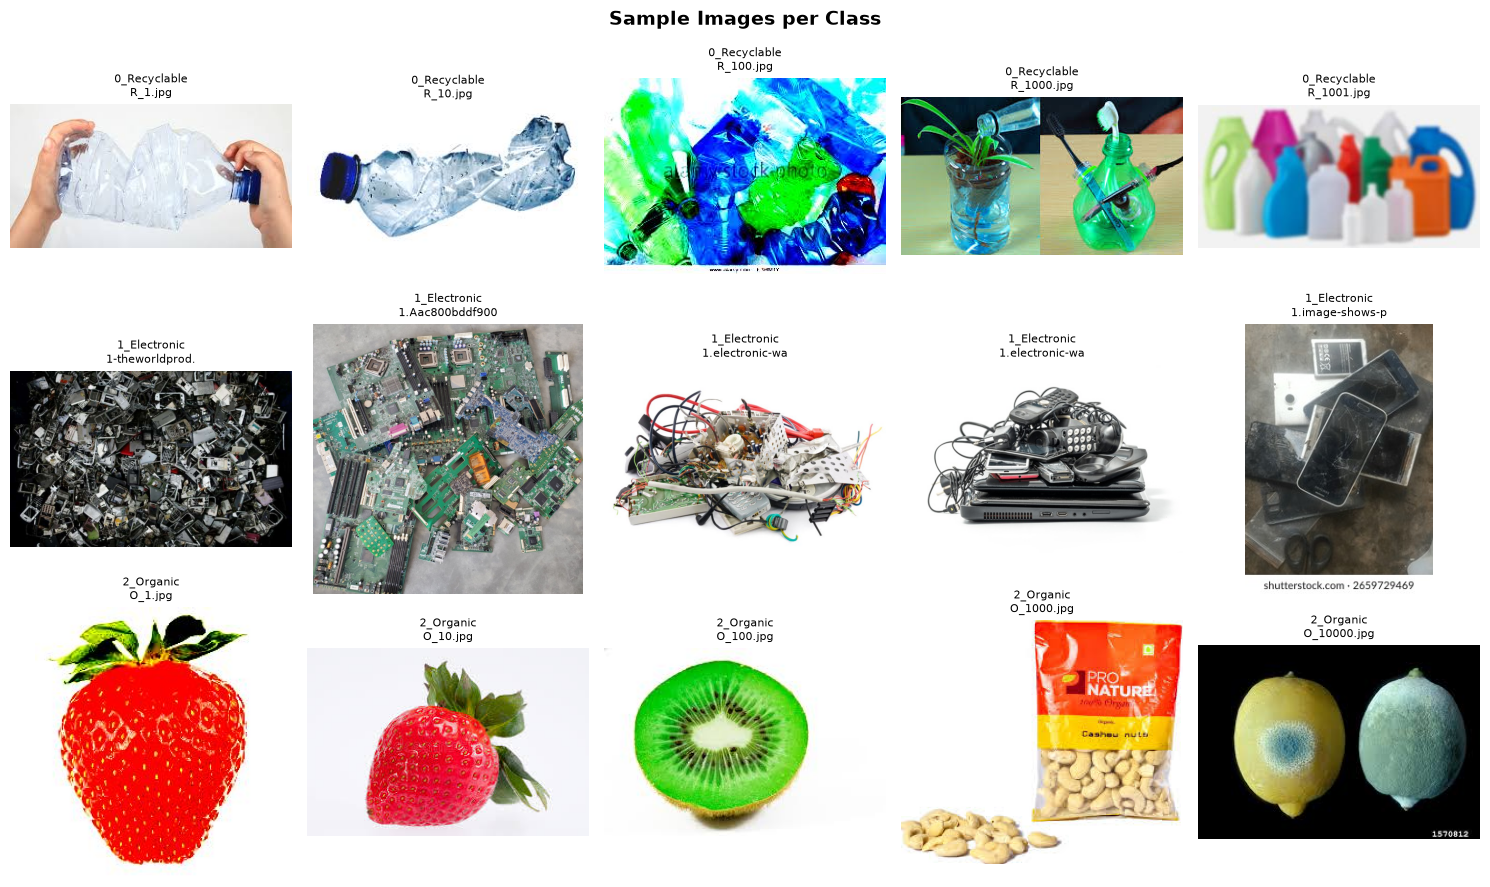

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for row, cls in enumerate(sorted(os.listdir(TRAIN_DIR))):
    cls_path = TRAIN_DIR / cls
    if not cls_path.is_dir():
        continue
    files = list(cls_path.iterdir())[:5]
    for col, fpath in enumerate(files):
        img = Image.open(_safe_path(fpath))
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'{cls}\n{fpath.name[:15]}', fontsize=8)
        axes[row, col].axis('off')
plt.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. File Path Panjang

In [ ]:
long_paths = []
for cls in os.listdir(TRAIN_DIR):
    cls_path = TRAIN_DIR / cls
    if not cls_path.is_dir():
        continue
    for fpath in cls_path.iterdir():
        if len(str(fpath)) > 240:
            long_paths.append((cls, fpath.name, len(str(fpath))))

if long_paths:
    print(f'Files with path > 240 chars: {len(long_paths)}')
    for cls, fname, length in long_paths:
        print(f'  {cls}/{fname}  ({length} chars)')
else:
    print('No long path issues. \u2705')

Files with path > 240 chars: 6
  1_Electronic/1.tumpukan-e-limbah-yang-kacau-dari-laptop-dan-suku-cadang-komputer-yang-dibuang-representasi-visual-yang-luar-biasa-dari-masalah-limbah-elektronik-yang-berkembang-dan-kebutuhan-akan-solusi-daur-ulang-berkelanjutan_73523-11403.jpg  (312 chars)
  1_Electronic/12.pile-discarded-motherboards-cpus-cables-disc-drives-hijacked-hardware-heap-concept-electronic-waste-tech-recycling-hardware-reuse-sustainable-technology-environmental-impact_864588-263287.jpg  (276 chars)
  1_Electronic/37.a-pile-of-discarded-electronic-waste-is-shown-including-a-laptop-television-keyboard-and-other-obsolete-devices-this-image-can-be-used-for-concepts-r-3E1WHH5.jpg  (246 chars)
  1_Electronic/63.piles-discarded-electronic-waste-recycled-laptop-parts-gathered-sustainable-reuse-recycling-process-concept-environmental-crisis-e-waste-management_73523-13964.jpg  (248 chars)
  1_Electronic/64.dampak-lingkungan-dari-ewaste-tangkap-konsekuensi-lingkungan-dari-pembuangan-ewas

---
## 8. Cek Train/Test Overlap (Data Leakage)
Apakah ada gambar test yang sama persis dengan gambar train?

In [ ]:
train_hashes = set(hash_map.keys())
test_hash_map = {}

for fpath in TEST_DIR.iterdir():
    with open(_safe_path(fpath), 'rb') as f:
        h = hashlib.md5(f.read()).hexdigest()
    test_hash_map[h] = fpath.name

overlap = set(test_hash_map.keys()) & train_hashes

print(f'Train images (unique): {len(train_hashes)}')
print(f'Test images: {len(test_hash_map)}')
if overlap:
    print(f'\u26a0\ufe0f  OVERLAP: {len(overlap)} gambar test ada di train! (data leakage)')
    for h in overlap:
        train_match = [f['fname'] for f in hash_map[h]]
        print(f'  Test: {test_hash_map[h]} === Train: {train_match}')
else:
    print('\u2705 No overlap. No data leakage.')

Train images (unique): 26465
Test images: 1458
⚠️  OVERLAP: 97 gambar test ada di train! (data leakage)
  Test: 811.jpg === Train: ['O_4768.jpg']
  Test: 668.jpg === Train: ['O_4501.jpg']
  Test: 287.jpg === Train: ['O_4610.jpg']
  Test: 1421.jpg === Train: ['O_4486.jpg']
  Test: 409.jpg === Train: ['O_4624.jpg']
  Test: 1288.jpg === Train: ['O_4825.jpg']
  Test: 1164.jpg === Train: ['O_4695.jpg']
  Test: 1183.jpg === Train: ['O_5000.jpg']
  Test: 545.jpg === Train: ['O_4785.jpg']
  Test: 1305.jpg === Train: ['O_4594.jpg']
  Test: 457.jpg === Train: ['O_4664.jpg']
  Test: 71.jpg === Train: ['O_4646.jpg']
  Test: 731.jpg === Train: ['O_4485.jpg']
  Test: 367.jpg === Train: ['O_4602.jpg']
  Test: 1380.jpg === Train: ['O_4693.jpg']
  Test: 1399.jpg === Train: ['O_4746.jpg']
  Test: 1082.jpg === Train: ['O_4649.jpg']
  Test: 929.jpg === Train: ['O_4636.jpg']
  Test: 289.jpg === Train: ['O_4574.jpg']
  Test: 1243.jpg === Train: ['O_4489.jpg']
  Test: 1343.jpg === Train: ['O_4617.jpg']
  Tes

---
## 9. Perceptual Hash (Gambar Mirip Visual)
Cek gambar yang **mirip secara visual** walau beda pixel (beda kompresi, resize, watermark).

> Scan sample 3.000 gambar, estimasi ~5-10 menit. Hasil bisa diskip kalo ga penting.

In [ ]:
def average_hash(img, hash_size=8):
    img = img.convert('L').resize((hash_size, hash_size), Image.LANCZOS)
    pixels = np.array(img, dtype=np.uint8)
    avg = pixels.mean()
    return pixels > avg

def hamming_distance(h1, h2):
    return np.sum(h1 != h2)

phash_map = defaultdict(list)
sampled = 0
max_sample = 3000
THRESHOLD = 6

for cls in os.listdir(TRAIN_DIR):
    cls_path = TRAIN_DIR / cls
    if not cls_path.is_dir():
        continue
    for fpath in cls_path.iterdir():
        if sampled >= max_sample:
            break
        with Image.open(_safe_path(fpath)) as img:
            h = average_hash(img)
        phash_map[cls].append({'fname': fpath.name, 'hash': h})
        sampled += 1
    if sampled >= max_sample:
        break

print(f'Sampled {sampled} images.')

similar_groups = []
for cls in phash_map:
    files = phash_map[cls]
    for a in range(len(files)):
        for b in range(a + 1, len(files)):
            dist = hamming_distance(files[a]['hash'], files[b]['hash'])
            if dist <= THRESHOLD and dist > 0:
                similar_groups.append((cls, files[a]['fname'], files[b]['fname'], dist))

print(f'Similar pairs (Hamming <={THRESHOLD}): {len(similar_groups)}')
for cls, f1, f2, dist in similar_groups[:15]:
    print(f'  {cls}: {f1} ~ {f2} (distance={dist})')
if len(similar_groups) > 15:
    print(f'  ... and {len(similar_groups) - 15} more')

Sampled 3000 images.
Similar pairs (Hamming <=6): 18567
  0_Recyclable: R_1004.jpg ~ R_1334.jpg (distance=5)
  0_Recyclable: R_1004.jpg ~ R_1501.jpg (distance=6)
  0_Recyclable: R_1008.jpg ~ R_1329.jpg (distance=5)
  0_Recyclable: R_101.jpg ~ R_1048.jpg (distance=5)
  0_Recyclable: R_101.jpg ~ R_1069.jpg (distance=3)
  0_Recyclable: R_101.jpg ~ R_1087.jpg (distance=3)
  0_Recyclable: R_101.jpg ~ R_1168.jpg (distance=5)
  0_Recyclable: R_101.jpg ~ R_120.jpg (distance=6)
  0_Recyclable: R_101.jpg ~ R_1212.jpg (distance=6)
  0_Recyclable: R_101.jpg ~ R_1230.jpg (distance=5)
  0_Recyclable: R_101.jpg ~ R_1281.jpg (distance=6)
  0_Recyclable: R_101.jpg ~ R_1306.jpg (distance=4)
  0_Recyclable: R_101.jpg ~ R_132.jpg (distance=3)
  0_Recyclable: R_101.jpg ~ R_1375.jpg (distance=3)
  0_Recyclable: R_101.jpg ~ R_1381.jpg (distance=5)
  ... and 18552 more


---
## 10. Backup Data (Opsional)
Backup folder train/ ke train_backup/ **sebelum** hapus duplikat.

In [ ]:
if not BACKUP_DIR.exists():
    print(f'Creating backup at {BACKUP_DIR}...')
    ret = os.system(f'robocopy "{TRAIN_DIR}" "{BACKUP_DIR}" /E /COPY:DAT /R:2 /W:2 /NDL /NFL /NJH /NJS')
    print('Backup completed! ✅')
else:
    print(f'Backup already exists at {BACKUP_DIR}')
    overwrite = input('Overwrite? (y/n): ').strip().lower()
    if overwrite == 'y':
        shutil.rmtree(BACKUP_DIR)
        ret = os.system(f'robocopy "{TRAIN_DIR}" "{BACKUP_DIR}" /E /COPY:DAT /R:2 /W:2 /NDL /NFL /NJH /NJS')
        print('Backup re-created!')

Backup already exists at d:\Kuliah\LOMBA\Satria-Data\main\big-data-big-trouble\data\raw\train_backup
Backup re-created!


---
## 11. Cleaning: Hapus Duplikat
Tiap grup duplikat keep 1 file, hapus sisanya.

In [ ]:
confirm = input('Yakin mau hapus duplikat? (y/n): ').strip().lower()
if confirm != 'y':
    print('Dibatalkan.')
else:
    removed_in_class = 0
    removed_cross = 0

    for h, files in dup_groups.items():
        classes = set(f['cls'] for f in files)
        for f in files[1:]:
            os.remove(f['path'])
            if len(classes) > 1:
                removed_cross += 1
            else:
                removed_in_class += 1

    print(f'Removed in-class duplicates: {removed_in_class}')
    print(f'Removed cross-class duplicates: {removed_cross}')
    print(f'Total removed: {removed_in_class + removed_cross}')
    print('Cleaning done! \u2705')

Removed in-class duplicates: 61
Removed cross-class duplicates: 1
Total removed: 62
Cleaning done! ✅


---
## 12. Final Count Setelah Cleaning

Final Class Distribution:
0_Recyclable                  9990 (removed 9)
1_Electronic                  3931 (removed 30)
2_Organic                    12544 (removed 23)
--------------------------------------------------
TOTAL                        26465 (removed 62)


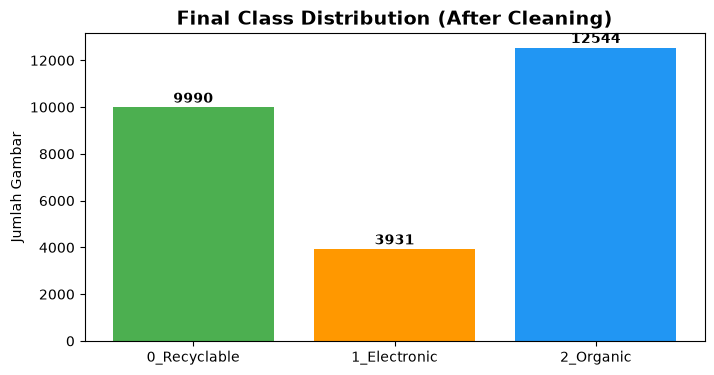

In [39]:
final_counts = {}
total_final = 0

for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = TRAIN_DIR / cls
    if not cls_path.is_dir():
        continue
    count = len(list(cls_path.iterdir()))
    final_counts[cls] = count
    total_final += count

print('Final Class Distribution:')
for cls, count in sorted(final_counts.items()):
    diff = class_counts[cls] - count
    print(f'{cls:<25} {count:>8} (removed {diff})')
print('-' * 50)
print(f'{"TOTAL":<25} {total_final:>8} (removed {total - total_final})')

plt.figure(figsize=(8, 4))
plt.bar(final_counts.keys(), final_counts.values(), color=colors)
plt.title('Final Class Distribution (After Cleaning)', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Gambar')
for i, (k, v) in enumerate(final_counts.items()):
    plt.text(i, v + 200, str(v), ha='center', fontweight='bold')
plt.show()
